# 5x1000 — Beneficiari e importi per ente

Dataset: `ade_cinque_per_mille` (Agenzia delle Entrate)

Analisi pubblica: [README](../README.md)

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

FIGS = Path("../figures")
FIGS.mkdir(parents=True, exist_ok=True)

con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")

URL = "https://storage.googleapis.com/dataciviclab-clean/ade_cinque_per_mille/2024/ade_cinque_per_mille_2024_clean.parquet"

def query(sql):
    result = con.execute(sql)
    cols = [desc[0] for desc in result.description]
    return pd.DataFrame(result.fetchall(), columns=cols)

df = query(f"SELECT * FROM read_parquet('{URL}')")
print(f"Righe: {len(df):,}, Colonne: {list(df.columns)}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Righe: 90,611, Colonne: ['anno', 'progressivo', 'codice_fiscale', 'denominazione', 'regione', 'sigla_provincia', 'comune', 'flag_ets_onlus', 'flag_asd', 'flag_ricerca_scientifica', 'flag_ricerca_sanitaria', 'flag_comune', 'flag_beni_culturali', 'flag_area_protetta', 'numero_scelte', 'importo_scelte_espresse', 'importo_scelte_generiche', 'importo_ripartizione', 'importo_totale_erogabile']


In [2]:
# 1. Categorie con classificazione esclusiva
cat_df = query(f"""
    SELECT
        CASE
            WHEN flag_ets_onlus = true AND flag_asd = false AND flag_comune = false
                 AND flag_ricerca_scientifica = false AND flag_ricerca_sanitaria = false THEN 'ETS / ONLUS'
            WHEN flag_ets_onlus = true AND flag_asd = false AND flag_comune = false
                 AND flag_ricerca_scientifica = true AND flag_ricerca_sanitaria = true THEN 'ETS + Ricerca scient. e san.'
            WHEN flag_ets_onlus = true AND flag_asd = false AND flag_comune = false
                 AND flag_ricerca_scientifica = true THEN 'ETS + Ricerca scientifica'
            WHEN flag_ets_onlus = true AND flag_asd = false AND flag_comune = false
                 AND flag_ricerca_sanitaria = true THEN 'ETS + Ricerca sanitaria'
            WHEN flag_asd = true THEN 'Sportive dilettantistiche'
            WHEN flag_ricerca_scientifica = true AND flag_ricerca_sanitaria = true THEN 'Ricerca scientifica e sanitaria'
            WHEN flag_ricerca_scientifica = true THEN 'Ricerca scientifica'
            WHEN flag_ricerca_sanitaria = true THEN 'Ricerca sanitaria'
            WHEN flag_comune = true THEN 'Comuni'
            WHEN flag_beni_culturali = true THEN 'Beni culturali'
            WHEN flag_area_protetta = true THEN 'Aree protette'
            ELSE 'Altro'
        END AS categoria,
        COUNT(*) AS num_enti,
        ROUND(SUM(COALESCE(importo_totale_erogabile, 0)), 0) AS importo_totale
    FROM read_parquet('{URL}')
    GROUP BY categoria
    ORDER BY importo_totale DESC
""")
print("Categorie:")
print(cat_df.to_string(index=False))
print(f"\nTotale: €{cat_df['importo_totale'].sum()/1e6:.1f}M")

Categorie:
                      categoria  num_enti  importo_totale
                    ETS / ONLUS     68122     309453479.0
   ETS + Ricerca scient. e san.        10      95763007.0
              Ricerca sanitaria        79      34805225.0
Ricerca scientifica e sanitaria        14      20512256.0
      Sportive dilettantistiche     13826      18321036.0
      ETS + Ricerca scientifica        57      17668208.0
                         Comuni      7909      15278492.0
            Ricerca scientifica       386       8319453.0
        ETS + Ricerca sanitaria         4        888423.0
                 Beni culturali       183        548053.0
                  Aree protette        21        405607.0

Totale: €522.0M


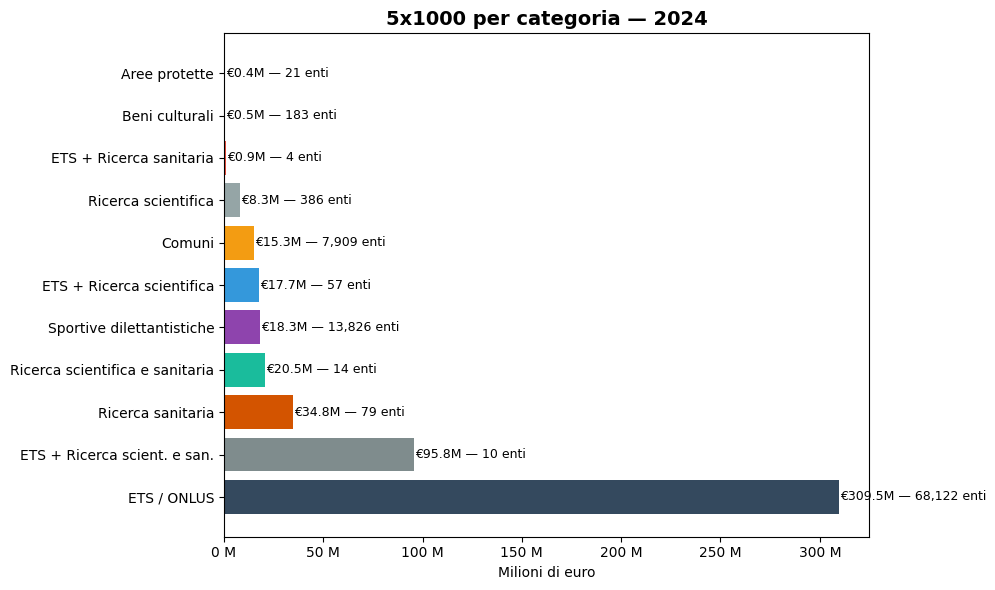

In [3]:
palette = ['#2c3e50', '#27ae60', '#e74c3c', '#95a5a6', '#f39c12', '#3498db', '#8e44ad', '#1abc9c', '#d35400', '#7f8c8d', '#34495e']

fig, ax = plt.subplots(figsize=(10, 6))
cats = cat_df.sort_values('importo_totale', ascending=True)
bars = ax.barh(cats['categoria'], cats['importo_totale'] / 1e6, color=palette[:len(cats)])
ax.set_xlabel('Milioni di euro')
ax.set_title('5x1000 per categoria — 2024', fontsize=14, fontweight='bold')
ax.invert_yaxis()

for bar, val, enti in zip(bars, cats['importo_totale'] / 1e6, cats['num_enti']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'€{val:.1f}M — {enti:,} enti', va='center', fontsize=9)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f} M'))
plt.tight_layout()
plt.savefig(FIGS / 'cinque-per-mille_categorie.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# 2. Importi per regione
reg_df = query(f"""
    SELECT regione,
           COUNT(*) AS num_enti,
           ROUND(SUM(COALESCE(importo_totale_erogabile, 0)), 0) AS importo_totale
    FROM read_parquet('{URL}')
    WHERE regione IS NOT NULL
    GROUP BY regione
    ORDER BY importo_totale DESC
""")

# Unifica Trentino
trentino_mask = reg_df['regione'].str.contains('TRENTINO', na=False)
trentino_row = reg_df[trentino_mask].sum(numeric_only=True)
reg_df = reg_df[~trentino_mask]
reg_df = pd.concat([
    reg_df,
    pd.DataFrame([{
        'regione': 'TRENTINO-ALTO ADIGE',
        'num_enti': int(trentino_row['num_enti']),
        'importo_totale': trentino_row['importo_totale']
    }])
], ignore_index=True)
reg_df = reg_df.sort_values('importo_totale', ascending=False)

print("Regioni:")
reg_df['imp_mln'] = reg_df['importo_totale'] / 1e6
print(reg_df[['regione', 'num_enti', 'imp_mln']].to_string(index=False))

Regioni:
              regione  num_enti    imp_mln
            LOMBARDIA     15013 187.213602
                LAZIO      8705  96.928716
       EMILIA ROMAGNA      7752  34.709689
             PIEMONTE      8048  32.297148
               VENETO      7732  31.176679
              TOSCANA      5838  21.670289
              LIGURIA      2320  20.357294
             CAMPANIA      5599  16.088515
               MARCHE      2072  14.854278
               PUGLIA      4929  14.153460
              SICILIA      5686  13.193953
FRIULI VENEZIA GIULIA      2462   8.987287
  TRENTINO-ALTO ADIGE      3304   8.627518
             CALABRIA      2811   5.361729
             SARDEGNA      2423   4.295175
              ABRUZZO      2108   4.137397
               UMBRIA      1532   3.990133
           BASILICATA       968   1.674264
               MOLISE       624   1.305141
        VALLE D'AOSTA       362   0.642025


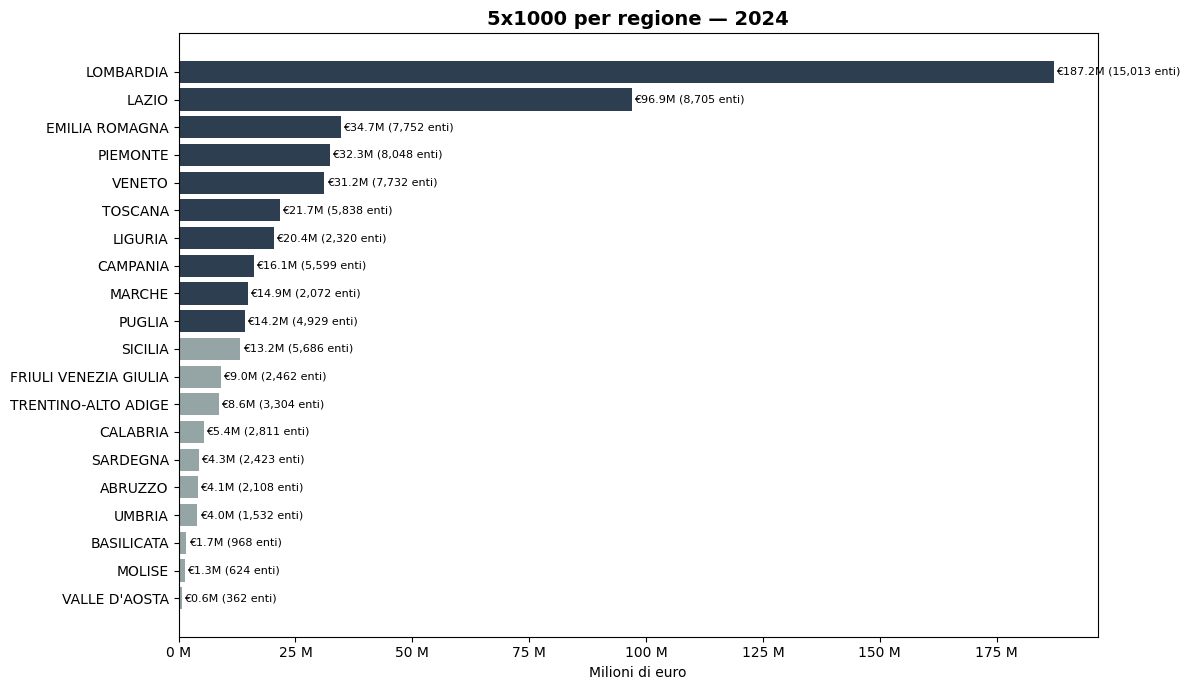

In [5]:
fig, ax = plt.subplots(figsize=(12, 7))
colors_reg = ['#2c3e50' if v >= reg_df['importo_totale'].median() else '#95a5a6' for v in reg_df['importo_totale']]
bars = ax.barh(reg_df['regione'], reg_df['importo_totale'] / 1e6, color=colors_reg)
ax.set_xlabel('Milioni di euro')
ax.set_title('5x1000 per regione — 2024', fontsize=14, fontweight='bold')
ax.invert_yaxis()

for bar, val, enti in zip(bars, reg_df['importo_totale'] / 1e6, reg_df['num_enti']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'€{val:.1f}M ({enti:,} enti)', va='center', fontsize=8)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f} M'))
plt.tight_layout()
plt.savefig(FIGS / 'cinque-per-mille_regioni.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# 3. Fasce di importo (solo ETS/ONLUS, esclusi enti senza importo)
ets_df = df[(df['flag_ets_onlus'] == True) & (df['flag_asd'] == False) & (df['flag_comune'] == False)].copy()

# Separa NULL e non-NULL
ets_null = ets_df[ets_df['importo_totale_erogabile'].isna()]
ets_valid = ets_df[ets_df['importo_totale_erogabile'].notna()]

bins = [0, 1000, 10000, 50000, 100000, 500000, 1000000, float('inf')]
labels_fasce = ['0-1k', '1k-10k', '10k-50k', '50k-100k', '100k-500k', '500k-1M', '>1M']
ets_valid = ets_valid.copy()
ets_valid['fascia'] = pd.cut(ets_valid['importo_totale_erogabile'], bins=bins, labels=labels_fasce, right=False)

fascia_groups = ets_valid.groupby('fascia', observed=False).agg(
    num_enti=('codice_fiscale', 'count'),
    importo_totale=('importo_totale_erogabile', 'sum')
).reset_index()

print(f"Enti ETS con importo: {len(ets_valid):,}")
print(f"Enti ETS senza importo (N/D): {len(ets_null):,}")
print(fasce_df := fascia_groups.to_string(index=False))

Enti ETS con importo: 53,185
Enti ETS senza importo (N/D): 15,008
   fascia  num_enti  importo_totale
     0-1k     24134     10901677.93
   1k-10k     24694     79895637.18
  10k-50k      3783     72052951.66
 50k-100k       300     20752917.05
100k-500k       222     45722187.86
  500k-1M        20     13386585.38
      >1M        32    181061159.76


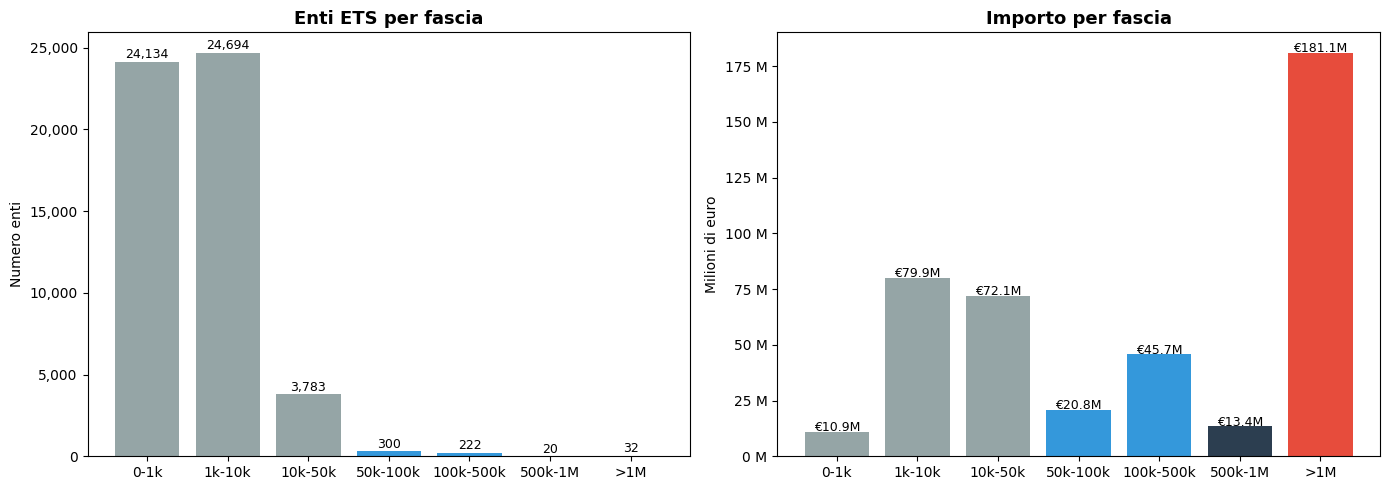

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors_fasce = ['#95a5a6', '#95a5a6', '#95a5a6', '#3498db', '#3498db', '#2c3e50', '#e74c3c']

# Enti per fascia
bars1 = ax1.bar(range(len(fascia_groups)), fascia_groups['num_enti'], color=colors_fasce)
ax1.set_xticks(range(len(fascia_groups)))
ax1.set_xticklabels(labels_fasce)
ax1.set_title('Enti ETS per fascia', fontsize=13, fontweight='bold')
ax1.set_ylabel('Numero enti')
for bar, val in zip(bars1, fascia_groups['num_enti']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}', ha='center', fontsize=9)

# Importo per fascia
bars2 = ax2.bar(range(len(fascia_groups)), fascia_groups['importo_totale'] / 1e6, color=colors_fasce)
ax2.set_xticks(range(len(fascia_groups)))
ax2.set_xticklabels(labels_fasce)
ax2.set_title('Importo per fascia', fontsize=13, fontweight='bold')
ax2.set_ylabel('Milioni di euro')
for bar, val in zip(bars2, fascia_groups['importo_totale'] / 1e6):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'€{val:.1f}M', ha='center', fontsize=9)

ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f} M'))
plt.tight_layout()
plt.savefig(FIGS / 'cinque-per-mille_fasce.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# 4. Verifica totali
totali = query(f"""
    SELECT COUNT(*) AS num_enti,
           SUM(numero_scelte) AS tot_scelte,
           ROUND(SUM(COALESCE(importo_totale_erogabile, 0)), 0) AS importo_totale
    FROM read_parquet('{URL}')
""")
print(f"Enti: {totali['num_enti'].values[0]:,}")
print(f"Scelte: {totali['tot_scelte'].values[0]:,}")
print(f"Importo totale: €{totali['importo_totale'].values[0]/1e6:.1f}M")

Enti: 90,611
Scelte: 15,145,758
Importo totale: €522.0M


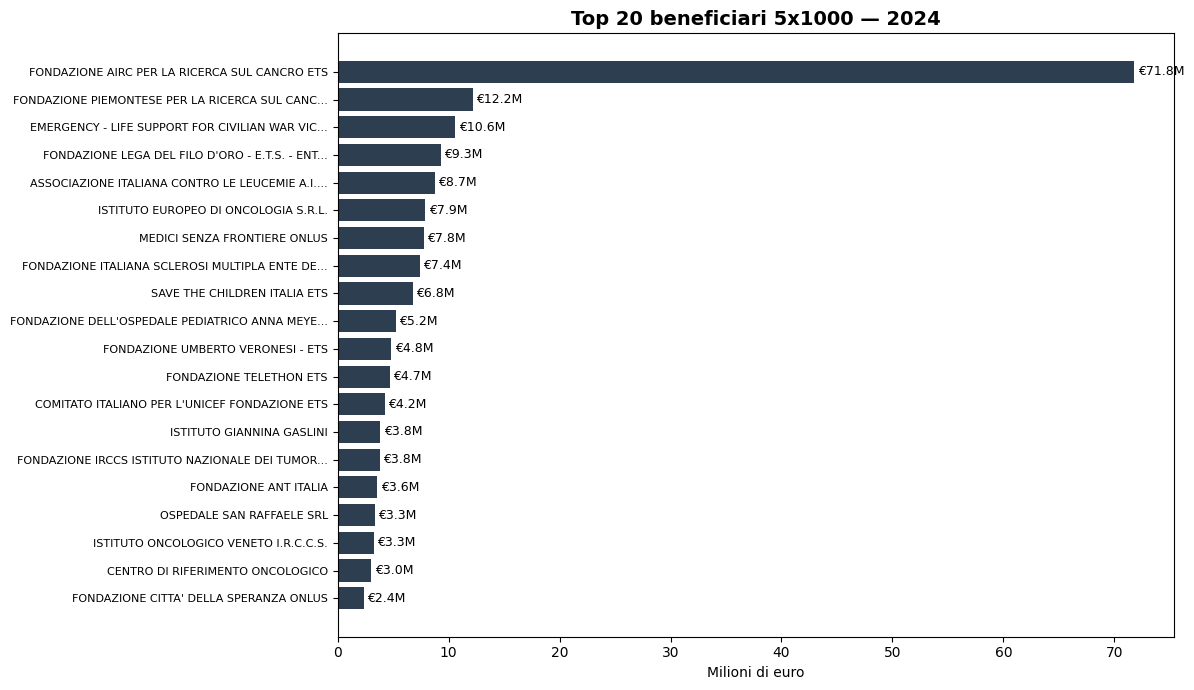

                                                                                    denominazione               regione  importo_totale
                                                    FONDAZIONE AIRC PER LA RICERCA SUL CANCRO ETS             LOMBARDIA      71799594.0
                                          FONDAZIONE PIEMONTESE PER LA RICERCA SUL CANCRO - ONLUS              PIEMONTE      12161686.0
EMERGENCY - LIFE SUPPORT FOR CIVILIAN WAR VICTIMS O.N.G. O.N.L.U S. IN BREVE EME RGENCY ONG ONLUS             LOMBARDIA      10608104.0
                                      FONDAZIONE LEGA DEL FILO D'ORO - E.T.S. - ENTE FILANTROPICO                MARCHE       9317053.0
                                            ASSOCIAZIONE ITALIANA CONTRO LE LEUCEMIE A.I.L. ONLUS                 LAZIO       8725832.0
                                                             ISTITUTO EUROPEO DI ONCOLOGIA S.R.L.             LOMBARDIA       7894769.0
                                                

In [9]:
# 5. Top 20 enti
top20 = query(f"""
    SELECT denominazione, regione, numero_scelte,
           ROUND(COALESCE(importo_totale_erogabile, 0), 0) AS importo_totale
    FROM read_parquet('{URL}')
    ORDER BY importo_totale_erogabile DESC NULLS LAST
    LIMIT 20
""")

fig, ax = plt.subplots(figsize=(12, 7))
yticks = range(len(top20))
labels_top = [f"{d[:45]}..." if len(d) > 45 else d for d in top20['denominazione']]
bars = ax.barh(yticks, top20['importo_totale'] / 1e6, color='#2c3e50')
ax.set_yticks(yticks)
ax.set_yticklabels(labels_top, fontsize=8)
ax.set_xlabel('Milioni di euro')
ax.set_title('Top 20 beneficiari 5x1000 — 2024', fontsize=14, fontweight='bold')
ax.invert_yaxis()

for bar, val in zip(bars, top20['importo_totale'] / 1e6):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'€{val:.1f}M', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGS / 'cinque-per-mille_top20.png', dpi=150, bbox_inches='tight')
plt.show()
print(top20[['denominazione', 'regione', 'importo_totale']].to_string(index=False))
print(f"\nFigure generate: {list(FIGS.glob('*.png'))}")